In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [32]:
Development = pd.read_csv(
    r"C:\Users\shaik\Downloads\Comprehensive-Measure-of-Well-Being-main\Comprehensive-Measure-of-Well-Being-main\Dataset\hdi.csv"
)
Development.head()

,Unnamed: 0,Id,Country,HDI Rank,HDI,Life expectancy,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,Change in HDI rank 2010-2015,...,Coefficient of human inequality,Inequality in life expectancy (%) 2010-2015,Inequality-adjusted life expectancy index,Inequality in education(%),Inequality-adjusted education index,Inequality in income (%),Inequality-adjusted income index,Income inequality (Quintile ratio) 2010-2015,Income inequality (Palma ratio) 2010-2015,Income inequality (Gini coefficient) 2010-2015
0,0,1,Norway,1.0,0.949,81.7,12.7,67614.0,5.0,0.0,...,5.4,3.3,0.918,2.4,0.894,10.4,0.882,3.8,0.9,25.9
1,1,2,Australia,2.0,0.939,82.5,13.2,42822.0,19.0,1.0,...,8.0,4.3,0.921,1.9,0.921,17.7,0.753,6.0,1.4,34.9
2,2,3,Switzerland,2.0,0.939,83.1,13.4,56364.0,7.0,0.0,...,8.4,3.8,0.934,5.7,0.840,15.7,0.806,4.9,1.2,31.6
3,3,4,Germany,4.0,0.926,81.1,13.2,45000.0,13.0,0.0,...,7.0,3.7,0.905,2.6,0.891,14.8,0.787,4.6,1.1,30.1
4,4,5,Denmark,5.0,0.925,80.4,12.7,44519.0,13.0,2.0,...,7.0,3.8,0.894,3.0,0.896,14.3,0.789,4.5,1.0,29.1


In [33]:
data1 = Development.head(20)
data1.shape
data1["Country"].unique()

<StringArray>
[                'Norway',              'Australia',            'Switzerland',
                'Germany',                'Denmark',              'Singapore',
            'Netherlands',                'Ireland',                'Iceland',
                 'Canada',          'United States', 'Hong Kong, China (SAR)',
            'New Zealand',                 'Sweden',          'Liechtenstein',
         'United Kingdom',                  'Japan',    'Korea (Republic of)',
                 'Israel',             'Luxembourg']
Length: 20, dtype: str

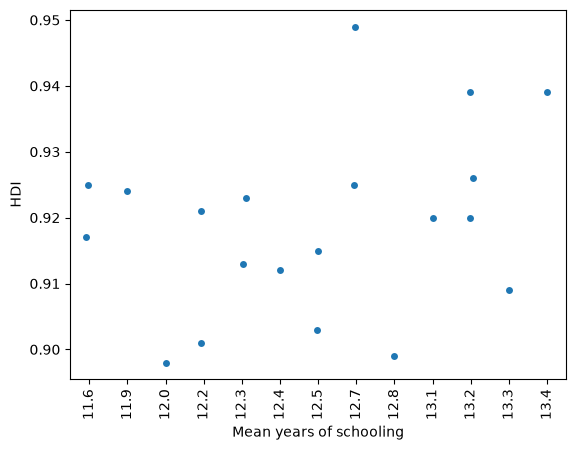

In [34]:
# Data Exploration
# Mean Years of Schooling

g = sns.stripplot(
    x="Mean years of schooling",
    y="HDI",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.show()

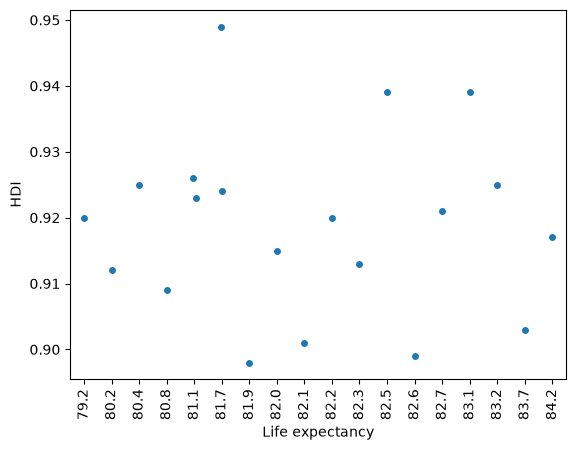

In [35]:
# Data Exploration
# Life Expectancy

g = sns.stripplot(
    x="Life expectancy",
    y="HDI",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.show()

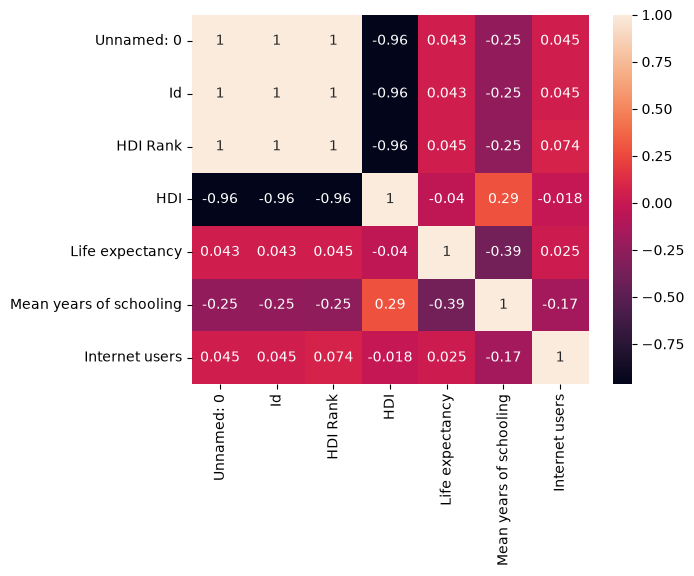

In [36]:
heat = data1.iloc[:, [0,1,3,4,5,6,67]]

sns.heatmap(heat.corr(), annot=True)
plt.show()

In [50]:
# Independent Variables (numeric only)

X = Development[[
    "Life expectancy",
    "Mean years of schooling",
    "Gross national income (GNI) per capita",
    "Internet users"
]]

X = X.fillna(X.mean())

# Dependent Variable

y = Development["HDI"]

y = y.fillna(y.mean())
print(X.columns)

Index(['Life expectancy', 'Mean years of schooling',
       'Gross national income (GNI) per capita', 'Internet users'],
      dtype='str')


In [38]:
# Finding the sum of null values in the selected columns

X.isnull().sum()

Country                                   0
Life expectancy                           5
Mean years of schooling                   7
Gross national income (GNI) per capita    2
Internet users                            4
dtype: int64

In [39]:
# Replacing the null values with the mean
X = X.copy()

numeric_cols = X.select_dtypes(include=['number']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

X.isnull().sum()

Country                                   0
Life expectancy                           0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
Internet users                            0
dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [52]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.01,0.02,0. ,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Life expectancy','Mean years of schooling', 'Gross national income (GNI) per capita','Internet users']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.01454
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [53]:
y_pred = reg.predict(x_test)

print(y_pred)

[0.59139818 0.93408985 0.56206074 0.69311523 0.73403162 0.5043261
 0.78073951 0.93191395 0.64490433 0.6636812  0.4177638  0.9142879
 0.69995524 0.93805825 0.51104604 0.66632221 0.79829041 0.7211698
 0.73121322 0.72049439]


In [56]:
import pickle
pickle.dump(reg,open('HDI.pkl','wb'))